### Load the master dataset ###

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv(r"C:\Users\shiv_\OneDrive\Desktop\AI-ScamShield\data\processed\master_dataset.csv")
df.head()

,label,message,source,scam_type
0,legit,"Go until jurong point, crazy.. Available only ...",sms,none
1,legit,Ok lar... Joking wif u oni...,sms,none
2,scam,Free entry in 2 a wkly comp to win FA Cup fina...,sms,unknown
3,legit,U dun say so early hor... U c already then say...,sms,none
4,legit,"Nah I don't think he goes to usf, he lives aro...",sms,none


#### Analysis the message lengths ####

In [4]:
df["message_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda x: len(str(x).split()))

df[["message_length", "word_count"]].describe()

,message_length,word_count
count,4.901900e+04,4.901900e+04
mean,2.228850e+03,3.695816e+02
std,7.700709e+04,1.593985e+04
min,1.000000e+00,0.000000e+00
25%,2.635000e+02,4.400000e+01
50%,1.239000e+03,2.010000e+02
75%,2.713000e+03,4.120000e+02
max,1.703669e+07,3.527576e+06


### Histplot: Scam VS Legit ###

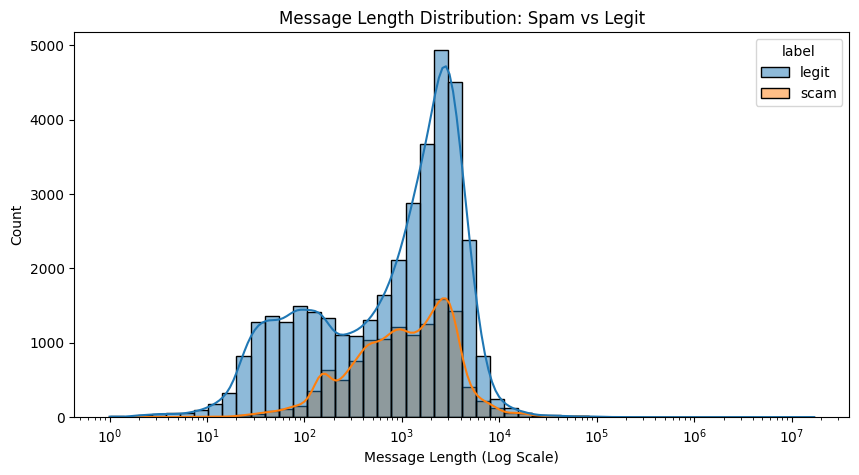

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, log_scale=(True, False))
plt.title('Message Length Distribution: Spam vs Legit')
plt.xlabel('Message Length (Log Scale)')
plt.show()


### Boxplots: Scam VS Legit ###

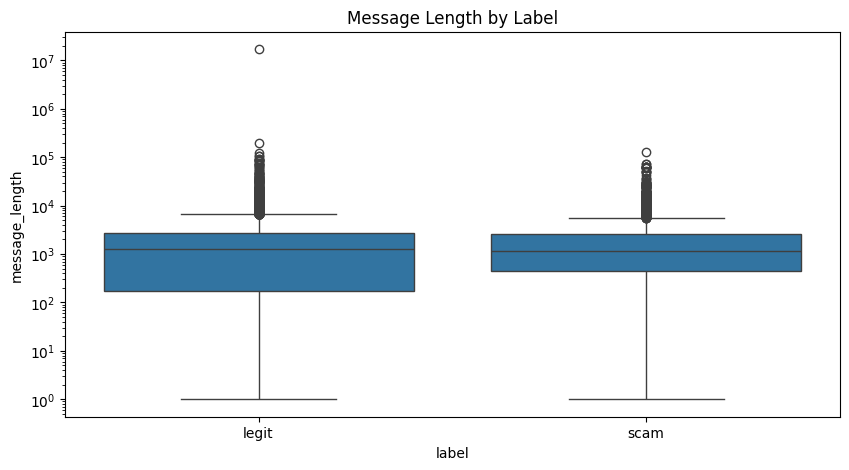

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='message_length')
plt.yscale('log')
plt.title('Message Length by Label')
plt.show()


### Word Count by Scam Type ###

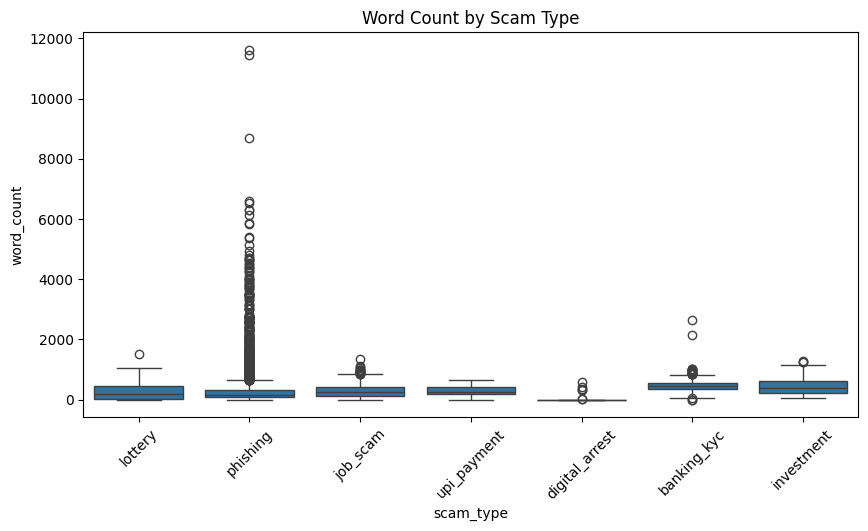

In [11]:
subset = df[~df['scam_type'].isin(['none', 'unknown'])]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x='scam_type', y='word_count')
plt.xticks(rotation=45)
plt.title('Word Count by Scam Type')
plt.show()

### Checking the message length by source ###

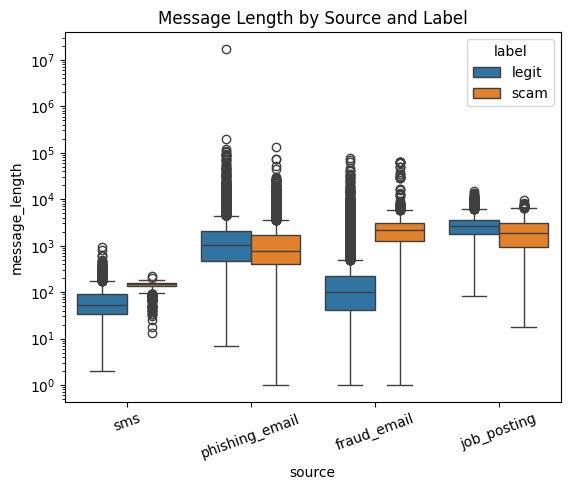

In [13]:
plt.Figure(figsize=(10, 5))
sns.boxplot(data=df, x='source', y='message_length', hue='label')
plt.yscale('log')
plt.title('Message Length by Source and Label')
plt.xticks(rotation=20)
plt.show()